In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'C:\sem5\nlp\Tweets.csv')

In [3]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [4]:
df.drop(['textID','selected_text','sentiment'],axis=1,inplace=True)

In [5]:
df

,text
0,"I`d have responded, if I were going"
1,Sooo SAD I will miss you here in San Diego!!!
2,my boss is bullying me...
3,what interview! leave me alone
4,"Sons of ****, why couldn`t they put them on t..."
...,...
27476,wish we could come see u on Denver husband l...
27477,I`ve wondered about rake to. The client has ...
27478,Yay good for both of you. Enjoy the break - y...
27479,But it was worth it ****.


In [8]:
df = df[~df['text'].isna()]

In [7]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

#nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    return sia.polarity_scores(text)

df['Sentiment Scores'] = df['text'].apply(get_sentiment_scores)

df = pd.concat([df.drop(['Sentiment Scores'],axis=1),df['Sentiment Scores'].apply(pd.Series)],axis=1)

C:\Users\HP\AppData\Local\Temp\ipykernel_13596\1731671588.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sentiment Scores'] = df['text'].apply(get_sentiment_scores)


In [8]:
df.head()

,text,neg,neu,pos,compound
0,"I`d have responded, if I were going",0.000,1.000,0.0,0.0000
1,Sooo SAD I will miss you here in San Diego!!!,0.474,0.526,0.0,-0.7437
2,my boss is bullying me...,0.494,0.506,0.0,-0.5994
3,what interview! leave me alone,0.538,0.462,0.0,-0.3595
4,"Sons of ****, why couldn`t they put them on t...",0.000,1.000,0.0,0.0000


In [9]:
from textblob import TextBlob

def get_polarity_subjectivity(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity


def get_analysis(score):
    
    if score < 0:
        return "Negative"
    elif score == 0:
        return "Neutral"
    else:
        return "Positive"

df[['Polarity','Subjectivity']] = df['text'].apply(get_polarity_subjectivity).apply(pd.Series)

df['analysis'] = df['Polarity'].apply(get_analysis)

In [10]:
df.head()

,text,neg,neu,pos,compound,Polarity,Subjectivity,analysis
0,"I`d have responded, if I were going",0.000,1.000,0.0,0.0000,0.000000,0.0,Neutral
1,Sooo SAD I will miss you here in San Diego!!!,0.474,0.526,0.0,-0.7437,-0.976562,1.0,Negative
2,my boss is bullying me...,0.494,0.506,0.0,-0.5994,0.000000,0.0,Neutral
3,what interview! leave me alone,0.538,0.462,0.0,-0.3595,0.000000,0.0,Neutral
4,"Sons of ****, why couldn`t they put them on t...",0.000,1.000,0.0,0.0000,0.000000,0.0,Neutral


In [11]:
df['analysis'].value_counts()

Positive    12619
Neutral      9427
Negative     5434
Name: analysis, dtype: int64

<Axes: >

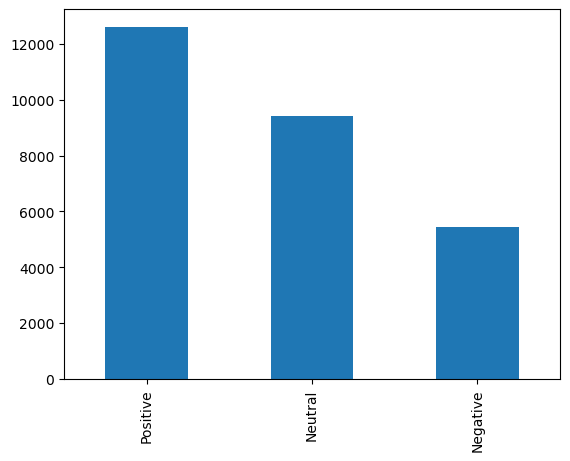

In [12]:
df['analysis'].value_counts().plot(kind='bar')

In [13]:
data = pd.read_csv('Tweets.csv')

In [14]:
data.drop(['textID','text','selected_text'],axis=1,inplace=True)

In [15]:
data.head()

,sentiment
0,neutral
1,negative
2,negative
3,negative
4,negative


In [16]:
df['sentiment'] = data['sentiment']

In [17]:
df['analysis'] = df['analysis'].str.lower()

In [20]:
df[df['analysis'] == df['sentiment']].shape

(16107, 9)

In [21]:
df[~(df['analysis'] == df['sentiment'])].shape

(11373, 9)

In [27]:
accuracy = (df[df['analysis'] == df['sentiment']].shape[0]/df.shape[0])*100

In [29]:
print('Accuracy :',accuracy,'%')

Accuracy : 58.61353711790394 %


Really bad accuracy

In [2]:
pip install -U sentence-transformers

   ---------------------------------------- 0.0/249.1 kB ? eta -:--:--
   - -------------------------------------- 10.2/249.1 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/249.1 kB 262.6 kB/s eta 0:00:01
   ----------- --------------------------- 71.7/249.1 kB 491.5 kB/s eta 0:00:01
   ----------------- -------------------- 112.6/249.1 kB 595.3 kB/s eta 0:00:01
   -------------------------------- ----- 215.0/249.1 kB 875.2 kB/s eta 0:00:01
   -------------------------------------- 249.1/249.1 kB 898.1 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from sentence_transformers import SentenceTransformer
sentences = ["This is an example sentence", "Each sentence is converted"]

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print(embeddings)


c:\Users\Shrawani\Downloads\Anaconda\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\Shrawani\Downloads\Anaconda\Lib\site-packages\huggingface_hub\file_download.py:159: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Shrawani\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

c:\Users\Shrawani\Downloads\Anaconda\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[[ 6.76569417e-02  6.34959564e-02  4.87131029e-02  7.93048963e-02
   3.74480709e-02  2.65277619e-03  3.93749177e-02 -7.09846616e-03
   5.93614057e-02  3.15370224e-02  6.00980818e-02 -5.29052354e-02
   4.06067409e-02 -2.59308442e-02  2.98428535e-02  1.12691487e-03
   7.35148937e-02 -5.03818579e-02 -1.22386597e-01  2.37028375e-02
   2.97265276e-02  4.24768776e-02  2.56337691e-02  1.99514348e-03
  -5.69190495e-02 -2.71597989e-02 -3.29035297e-02  6.60248995e-02
   1.19007193e-01 -4.58791330e-02 -7.26214200e-02 -3.25840116e-02
   5.23414016e-02  4.50553410e-02  8.25305004e-03  3.67024243e-02
  -1.39415674e-02  6.53918684e-02 -2.64272075e-02  2.06393175e-04
  -1.36643527e-02 -3.62811014e-02 -1.95043907e-02 -2.89738420e-02
   3.94270532e-02 -8.84090662e-02  2.62423488e-03  1.36713171e-02
   4.83062454e-02 -3.11566181e-02 -1.17329188e-01 -5.11690676e-02
  -8.85287672e-02 -2.18963325e-02  1.42986281e-02  4.44167778e-02
  -1.34816021e-02  7.43392631e-02  2.66382936e-02 -1.98762678e-02
   1.79191

In [4]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

#Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)


# Sentences we want sentence embeddings for
sentences = ['This is an example sentence', 'Each sentence is converted']

# Load model from HuggingFace Hub
tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
model = AutoModel.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')

# Tokenize sentences
encoded_input = tokenizer(sentences, padding=True, truncation=True, return_tensors='pt')

# Compute token embeddings
with torch.no_grad():
    model_output = model(**encoded_input)

# Perform pooling
sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])

# Normalize embeddings
sentence_embeddings = F.normalize(sentence_embeddings, p=2, dim=1)

print("Sentence embeddings:")
print(sentence_embeddings)


Sentence embeddings:
tensor([[ 6.7657e-02,  6.3496e-02,  4.8713e-02,  7.9305e-02,  3.7448e-02,
          2.6528e-03,  3.9375e-02, -7.0985e-03,  5.9361e-02,  3.1537e-02,
          6.0098e-02, -5.2905e-02,  4.0607e-02, -2.5931e-02,  2.9843e-02,
          1.1269e-03,  7.3515e-02, -5.0382e-02, -1.2239e-01,  2.3703e-02,
          2.9727e-02,  4.2477e-02,  2.5634e-02,  1.9951e-03, -5.6919e-02,
         -2.7160e-02, -3.2904e-02,  6.6025e-02,  1.1901e-01, -4.5879e-02,
         -7.2621e-02, -3.2584e-02,  5.2341e-02,  4.5055e-02,  8.2531e-03,
          3.6702e-02, -1.3942e-02,  6.5392e-02, -2.6427e-02,  2.0639e-04,
         -1.3664e-02, -3.6281e-02, -1.9504e-02, -2.8974e-02,  3.9427e-02,
         -8.8409e-02,  2.6242e-03,  1.3671e-02,  4.8306e-02, -3.1157e-02,
         -1.1733e-01, -5.1169e-02, -8.8529e-02, -2.1896e-02,  1.4299e-02,
          4.4417e-02, -1.3482e-02,  7.4339e-02,  2.6638e-02, -1.9876e-02,
          1.7919e-02, -1.0605e-02, -9.0426e-02,  2.1327e-02,  1.4120e-01,
         -6.4718e